# Static Move Prediction Draft

## Setup Environment && Load Libraries

In [98]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
from dataclasses import dataclass

import mlflow
import optuna

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight

from chesswinnerprediction.static_move.models.static_move_base import StaticMoveBaseModel

from config import RANDOM_STATE
from chesswinnerprediction.static_move.utils import load_train_valid_test, setup_mlflow, log_prediction

## Setup MLflow

In [100]:
setup_mlflow(experiment_name="Static Move Prediction")

## Load Data

In [112]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test(drop_event=True)

train_sample_weight = X_train["sample_weight"]
X_train.drop(columns=["sample_weight"], inplace=True)

valid_sample_weight = X_valid["sample_weight"]
X_valid.drop(columns=["sample_weight"], inplace=True)

In [113]:
eval_and_is_checkmate = {
    X_train.columns.get_loc("i_move"),
    X_train.columns.get_loc("eval"),
    X_train.columns.get_loc("is_checkmate_countdown"),
}
board_features = {
    X_train.columns.get_loc("i_move"),
    X_train.columns.get_loc("w_score"),
    X_train.columns.get_loc("b_score"),
    X_train.columns.get_loc("n_pieces"),
}
eval_and_board = eval_and_is_checkmate.union(board_features)

time_control = {
    X_train.columns.get_loc("i_move"),
    X_train.columns.get_loc("GameDurations_norm"),
    X_train.columns.get_loc("black_remaining_time_norm"),
    X_train.columns.get_loc("white_remaining_time_norm"),
    X_train.columns.get_loc("time_diff_norm"),
    X_train.columns.get_loc("IncrementTime"),
    X_train.columns.get_loc("BaseTime"),
}

time_control_extra = {
    X_train.columns.get_loc("black_time_will_end_on_move"),
    X_train.columns.get_loc("white_time_will_end_on_move"),
    X_train.columns.get_loc("black_increment_pct_in_time_per_move"),
    X_train.columns.get_loc("black_increment_pct_in_time_per_move"),
    X_train.columns.get_loc("black_time_per_move"),
    X_train.columns.get_loc("white_time_per_move"),
    X_train.columns.get_loc("i_move"),
}

all_features = set(range(X_train.shape[1]))

interaction_cst = [
    eval_and_is_checkmate,
    board_features,
    eval_and_board,
    time_control,
    time_control_extra,
    all_features,
]

In [114]:
X_test.head(10)

,eval,EloDiff,MeanElo,BaseTime,IncrementTime,time_diff_norm,white_remaining_time_norm,black_remaining_time_norm,GameDurations_norm,is_checkmate_countdown,i_move,w_score,b_score,n_pieces,white_time_per_move,black_time_per_move,white_increment_pct_in_time_per_move,black_increment_pct_in_time_per_move,white_time_will_end_on_move,black_time_will_end_on_move
0,0.26,-64,1714.0,600,0,0.000000,1.000000,1.000000,0.000000,False,1,39,39,32,0.000001,0.000001,0.0,0.0,200.0,200.0
1,0.26,-64,1714.0,600,0,0.000000,1.000000,1.000000,0.000000,False,2,39,39,32,0.000001,0.000001,0.0,0.0,200.0,200.0
2,0.14,-64,1714.0,600,0,-0.001667,0.998333,1.000000,0.001667,False,3,39,39,32,0.000557,0.000001,0.0,0.0,200.0,200.0
3,0.29,-64,1714.0,600,0,0.006667,0.998333,0.991667,0.010000,False,4,39,39,32,0.000418,0.002084,0.0,0.0,200.0,200.0
4,0.17,-64,1714.0,600,0,0.003333,0.995000,0.991667,0.013333,False,5,39,39,32,0.001001,0.001668,0.0,0.0,200.0,200.0
5,0.12,-64,1714.0,600,0,0.006667,0.995000,0.988333,0.016667,False,6,39,39,32,0.000834,0.001945,0.0,0.0,200.0,200.0
6,0.10,-64,1714.0,600,0,0.003333,0.991667,0.988333,0.020000,False,7,39,39,32,0.001191,0.001668,0.0,0.0,200.0,200.0
7,0.37,-64,1714.0,600,0,0.010000,0.991667,0.981667,0.026667,False,8,39,39,32,0.001043,0.002293,0.0,0.0,200.0,200.0
8,0.33,-64,1714.0,600,0,0.010000,0.991667,0.981667,0.026667,False,9,39,39,32,0.000927,0.002038,0.0,0.0,200.0,200.0
9,0.91,-64,1714.0,600,0,0.021667,0.991667,0.970000,0.038333,False,10,39,39,32,0.000834,0.003001,0.0,0.0,200.0,200.0


In [115]:
new_x_data_con = (X_train["i_move"] > 40)
X_train = X_train[new_x_data_con]
y_train = y_train[new_x_data_con]
train_sample_weight = train_sample_weight[new_x_data_con]

## Optuna

In [116]:
def get_model(trial: optuna.Trial, model_type, hist_gb_class_weight=None):
    if model_type == HistGradientBoostingClassifier.__name__:
        model = HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            tol=1e-5,
            n_iter_no_change=10,
            learning_rate=trial.suggest_float("hist_learning_rate", 5e-4, 1e-2, log=True),
            max_iter=trial.suggest_int("hist_max_iter", 800, 1600),
            max_depth=trial.suggest_int("hist_max_depth", 5, 20),
            min_samples_leaf=trial.suggest_int("hist_min_samples_leaf", 10, X_train.shape[0]//8),
            max_leaf_nodes=trial.suggest_int("hist_max_leaf_nodes", 50, 300),
            # l2_regularization=trial.suggest_float("hist_l2_regularization", 1e-7, 1, log=True),
            max_bins=trial.suggest_int("hist_max_bins", 100, 255),
            # categorical_features=["Event"],
            interaction_cst=interaction_cst,
            class_weight=hist_gb_class_weight,
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

In [117]:
@dataclass
class BestModel:
    trial: optuna.Trial = None
    score: float = 0.0
    run_id: str = ""
    model: StaticMoveBaseModel = None

In [118]:
class Objective:
    def __init__(self, parent_run_id, model_types, fit_kwargs, get_model_kwargs, score_model_kwargs):
        self.parent_run_id = parent_run_id
        self.model_types = model_types
        self.fit_kwargs = fit_kwargs
        self.get_model_kwargs = get_model_kwargs
        self.score_model_kwargs = score_model_kwargs
        self._best_models = self.__generate_best_model_dict()
        
    def __call__(self, trial: optuna.Trial):
        model_type = trial.suggest_categorical("model_type", self.model_types)

        estimator = get_model(trial, model_type, **self.get_model_kwargs)
        model = StaticMoveBaseModel(estimator=estimator)
        fit_kwargs = self.fit_kwargs[model_type]
        model.fit(X_train, y_train, **fit_kwargs)

        model.score(X_valid, y_valid)
        self.log_trial(trial, model)
        
        return model.balanced_accuracy
    
    def log_trial(self, trial, model: StaticMoveBaseModel):
        score = model.balanced_accuracy
        model_type = trial.params["model_type"]
        if score > self._best_models[model_type].score:
            self._best_models[model_type].model = model
            self._best_models[model_type].score = score
            self._best_models[model_type].trial = trial
        
        
        run_id = self._best_models[model_type].run_id
        with mlflow.start_run(nested=True, run_id=run_id, parent_run_id=self.parent_run_id) as model_run:
            with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}", parent_run_id=model_run.info.run_id):
                # mlflow.log_params(trial.params)
                model.log_trial()
        
    def log_best(self, trial):
        best_mode = self._best_models[trial.params["model_type"]]
        mlflow.log_params(best_mode.trial.params)
        best_mode.model.log_trial()
        
        for model_type in self.model_types:
            best_model_data = self._best_models[model_type]
            if best_model_data.model is None:
                mlflow.delete_run(best_model_data.run_id)
                continue
            with mlflow.start_run(nested=True, run_id=best_model_data.run_id, parent_run_id=self.parent_run_id):
                mlflow.log_params(best_model_data.trial.params)
                best_model_data.model.log_trial()
                
    def log_prediction(self, trial, x, y, set_name):
        model = self._best_models[trial.params["model_type"]].model
        log_prediction(model, x, y, set_name)

          
    def __generate_best_model_dict(self):
        best_models = {}
        for model_type in self.model_types:
            with mlflow.start_run(nested=True, run_name=model_type, parent_run_id=self.parent_run_id) as model_run:
                best_models[model_type] = BestModel(run_id=model_run.info.run_id)
        return best_models

## Study Run

In [119]:
def study_run(description, study_name, objective_kwargs):
    study = optuna.create_study(direction="maximize", study_name=study_name)
    
    with mlflow.start_run(run_name=study_name, description=description) as main_run:
        objective = Objective(main_run.info.run_id, **objective_kwargs)
        study.optimize(objective, n_trials=24, show_progress_bar=True)
        objective.log_best(study.best_trial)
        
        objective.log_prediction(study.best_trial, X_train, y_train, set_name="X_train")
        objective.log_prediction(study.best_trial, X_valid, y_valid, set_name="X_valid")
        objective.log_prediction(study.best_trial, X_test, y_test, set_name="X_test")
    
    return study

In [120]:
models_types = [HistGradientBoostingClassifier.__name__]

study_kwargs_1 = {
    "study_name": "NO Class Weights; NO Sample Weights",
    "objective_kwargs": {
        "model_types": models_types,
        "fit_kwargs": {HistGradientBoostingClassifier.__name__: {}},
        "get_model_kwargs": {"hist_gb_class_weight": None},
        "score_model_kwargs": {"sample_weight": None},
    }
}
study_kwargs_2 = {
    "study_name": "Class Weights",
    "objective_kwargs": {
        "model_types": models_types,
        "fit_kwargs": {HistGradientBoostingClassifier.__name__: {}},
        "get_model_kwargs": {"hist_gb_class_weight": "balanced"},
        "score_model_kwargs": {"sample_weight": None},
    }
}
study_kwargs_3 = {
    "study_name": "Sample Weights",
    "objective_kwargs": {
        "model_types": models_types,
        "fit_kwargs": {HistGradientBoostingClassifier.__name__: {"sample_weight": train_sample_weight}},
        "get_model_kwargs": {"hist_gb_class_weight": None},
        "score_model_kwargs": {"sample_weight": None},
    }
}
study_kwargs_4 = {
    "study_name": "Class Weights && Sample Weights",
    "objective_kwargs": {
        "model_types": models_types,
        "fit_kwargs": {HistGradientBoostingClassifier.__name__: {"sample_weight": train_sample_weight}},
        "get_model_kwargs": {"hist_gb_class_weight": "balanced"},
        "score_model_kwargs": {"sample_weight": valid_sample_weight},
        # "score_model_kwargs": {"sample_weight": compute_class_weight("balanced", classes=y_valid.unique(), y=y_valid)},
    }
}

[I 2024-08-31 21:35:51,530] A new study created in memory with name: Class Weights && Sample Weights


  0%|          | 0/24 [00:00<?, ?it/s]

[I 2024-08-31 21:35:57,450] Trial 0 finished with value: 0.5379036972322607 and parameters: {'model_type': 'HistGradientBoostingClassifier', 'hist_learning_rate': 0.003295824568170451, 'hist_max_iter': 1004, 'hist_max_depth': 17, 'hist_min_samples_leaf': 2477, 'hist_max_leaf_nodes': 104, 'hist_max_bins': 184}. Best is trial 0 with value: 0.5379036972322607.
[I 2024-08-31 21:36:21,478] Trial 1 finished with value: 0.5129912760025048 and parameters: {'model_type': 'HistGradientBoostingClassifier', 'hist_learning_rate': 0.00280383315115061, 'hist_max_iter': 1598, 'hist_max_depth': 19, 'hist_min_samples_leaf': 283, 'hist_max_leaf_nodes': 223, 'hist_max_bins': 112}. Best is trial 0 with value: 0.5379036972322607.
[I 2024-08-31 21:36:39,811] Trial 2 finished with value: 0.5130441020675782 and parameters: {'model_type': 'HistGradientBoostingClassifier', 'hist_learning_rate': 0.003764436711387449, 'hist_max_iter': 1162, 'hist_max_depth': 14, 'hist_min_samples_leaf': 235, 'hist_max_leaf_nodes':

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (8,) + inhomogeneous part.

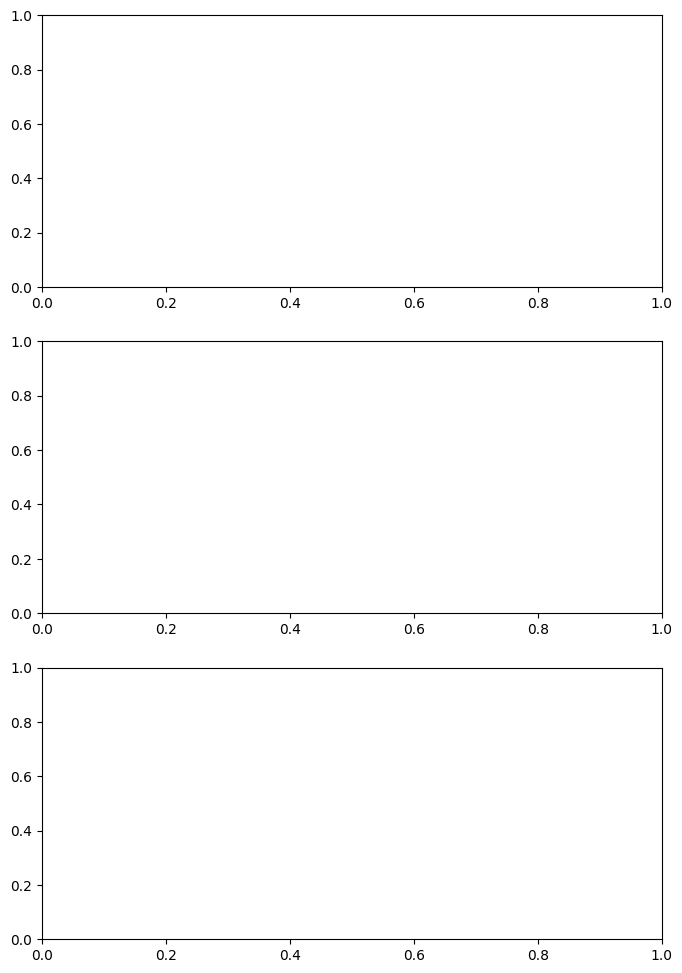

In [121]:
run_description = "class && sample weights; valid with sample_weights; 3 bin; data fixed; time features added; i_move > 40"

st = study_run(description=run_description, **study_kwargs_4)

## Feature Importance

In [63]:
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

In [58]:
best_model: HistGradientBoostingClassifier = get_model(st.best_trial, st.best_trial.params["model_type"])

In [59]:
best_model.fit(X_train, y_train)

HistGradientBoostingClassifier(interaction_cst=[{0, 9}, {11, 12, 13},
                                                {0, 9, 11, 12, 13},
                                                {3, 4, 5, 6, 7, 8, 10},
                                                {0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                 10, 11, 12, 13}],
                               learning_rate=0.0014601334506041082,
                               max_bins=119, max_depth=13, max_iter=1359,
                               max_leaf_nodes=50, min_samples_leaf=1056,
                               random_state=42, tol=1e-05)

In [60]:
y_pred = best_model.predict(X_test)

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0-1       0.68      0.69      0.69    299567
         1-0       0.68      0.72      0.70    307376
     1/2-1/2       0.57      0.11      0.19     28847

    accuracy                           0.68    635790
   macro avg       0.64      0.51      0.53    635790
weighted avg       0.68      0.68      0.67    635790



## show feature importance

In [64]:
result = permutation_importance(best_model, X_train, y_train, n_repeats=4, random_state=42, n_jobs=-1)

In [65]:
for i in result.importances_mean.argsort()[::-1]:
    print(f"{X_train.columns[i]}: {result.importances_mean[i]:.4f} +/- {result.importances_std[i]:.4f}")

eval: 0.1474 +/- 0.0008
EloDiff: 0.0464 +/- 0.0010
time_diff_norm: 0.0212 +/- 0.0007
white_remaining_time_norm: 0.0140 +/- 0.0002
black_remaining_time_norm: 0.0104 +/- 0.0005
BaseTime: 0.0099 +/- 0.0005
MeanElo: 0.0097 +/- 0.0004
w_score: 0.0077 +/- 0.0004
b_score: 0.0051 +/- 0.0008
IncrementTime: 0.0051 +/- 0.0007
is_checkmate_countdown: 0.0043 +/- 0.0007
GameDurations_norm: 0.0016 +/- 0.0003
i_move: 0.0013 +/- 0.0001
n_pieces: 0.0005 +/- 0.0001
